In [56]:
from metaflow import Flow
from color_brains.model.rgb_model_flow import RGBModelFlow
from color_brains.data_enrichment.rgb_feature_enrichment_flow import RGBFeatureEnrichmentFlow
import pandas as pdz
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [63]:
model_flow = Flow(RGBModelFlow.__name__)
latest_run = model_flow.latest_successful_run
xgb_reg = latest_run.data.xgb_reg
dependent_variables = latest_run.data.x_cols
dataset = Flow(RGBFeatureEnrichmentFlow.__name__).latest_run.data.dataset
cmap_name_col = Flow(RGBFeatureEnrichmentFlow.__name__).latest_run.data.cmap_column_name
"""
complete failure - 
Run('RGBModelFlow/1726322386924671')

moderate success
Run('RGBModelFlow/1727060336171372')

worse
Run('RGBModelFlow/1728076916444087')

"""
dependent_variables
current_rgb = ['red', 'green', 'blue']
start_rgb = [c for c in dependent_variables if c.startswith('start')]
previous_rgb = [c for c in dependent_variables if c.startswith('previous')]
end_rgb = [c for c in dependent_variables if c.startswith('end')]
model_flow.latest_successful_run

Run('RGBModelFlow/1728077973495543')

In [64]:
dataset

,colormap_name,red,green,blue,previous_red,previous_green,previous_blue,start_red,start_green,start_blue,...,middle_red,middle_green,middle_blue,cos_theta_start,cos_theta_middle,cos_theta_previous,cos_theta_end,next_red,next_green,next_blue
513,sequential.Purples,0.986636,0.982591,0.991173,0.988235,0.984314,0.992157,0.988235,0.984314,0.992157,...,0.617762,0.602138,0.783453,1.000000,0.992929,1.000000,0.777654,0.985037,0.980869,0.990188
514,sequential.Purples,0.985037,0.980869,0.990188,0.986636,0.982591,0.991173,0.988235,0.984314,0.992157,...,0.617762,0.602138,0.783453,1.000000,0.992968,1.000000,0.777849,0.983437,0.979146,0.989204
515,sequential.Purples,0.983437,0.979146,0.989204,0.985037,0.980869,0.990188,0.988235,0.984314,0.992157,...,0.617762,0.602138,0.783453,1.000000,0.993007,1.000000,0.778045,0.981838,0.977424,0.988220
516,sequential.Purples,0.981838,0.977424,0.988220,0.983437,0.979146,0.989204,0.988235,0.984314,0.992157,...,0.617762,0.602138,0.783453,0.999999,0.993046,1.000000,0.778241,0.980238,0.975702,0.987236
517,sequential.Purples,0.980238,0.975702,0.987236,0.981838,0.977424,0.988220,0.988235,0.984314,0.992157,...,0.617762,0.602138,0.783453,0.999999,0.993086,1.000000,0.778438,0.978639,0.973979,0.986251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63482,scientific.Oleron_256_r,0.129412,0.180392,0.380392,0.137255,0.184314,0.384314,0.992157,0.992157,0.901961,...,0.901961,0.949020,1.000000,0.885406,0.921032,0.999903,0.998649,0.125490,0.172549,0.372549
63483,scientific.Oleron_256_r,0.125490,0.172549,0.372549,0.129412,0.180392,0.380392,0.992157,0.992157,0.901961,...,0.901961,0.949020,1.000000,0.882164,0.918278,0.999961,0.998995,0.117647,0.168627,0.368627
63484,scientific.Oleron_256_r,0.117647,0.168627,0.368627,0.125490,0.172549,0.372549,0.992157,0.992157,0.901961,...,0.901961,0.949020,1.000000,0.875662,0.912832,0.999889,0.999499,0.113725,0.160784,0.360784
63485,scientific.Oleron_256_r,0.113725,0.160784,0.360784,0.117647,0.168627,0.368627,0.992157,0.992157,0.901961,...,0.901961,0.949020,1.000000,0.871874,0.909590,0.999953,0.999726,0.105882,0.156863,0.356863


In [65]:
viridis = dataset[dataset.colormap_name == 'perceptually_uniform_sequential.viridis']
viridis.cos_theta_end.describe()

count    255.000000
mean       0.750950
std        0.138835
min        0.556992
25%        0.657045
50%        0.664889
75%        0.881200
max        1.000000
Name: cos_theta_end, dtype: float64

In [66]:
dataset.colormap_name.unique()

array(['sequential.Purples', 'sequential.Purples_r', 'sequential.Blues',
       'sequential.Blues_r', 'sequential.Greens', 'sequential.Greens_r',
       'sequential.Oranges', 'sequential.Oranges_r', 'sequential.Reds',
       'sequential.Reds_r', 'sequential.YlOrBr', 'sequential.YlOrBr_r',
       'sequential.YlOrRd', 'sequential.YlOrRd_r', 'sequential.OrRd',
       'sequential.OrRd_r', 'sequential.PuRd', 'sequential.PuRd_r',
       'sequential.RdPu', 'sequential.RdPu_r', 'sequential.BuPu',
       'sequential.BuPu_r', 'sequential.GnBu', 'sequential.GnBu_r',
       'sequential.PuBu', 'sequential.PuBu_r', 'sequential.YlGnBu',
       'sequential.YlGnBu_r', 'sequential.PuBuGn', 'sequential.PuBuGn_r',
       'sequential.BuGn', 'sequential.BuGn_r', 'sequential.YlGn',
       'sequential.YlGn_r', 'perceptually_uniform_sequential.viridis',
       'perceptually_uniform_sequential.viridis_r',
       'perceptually_uniform_sequential.plasma',
       'perceptually_uniform_sequential.plasma_r',
       

'Ideal Output'

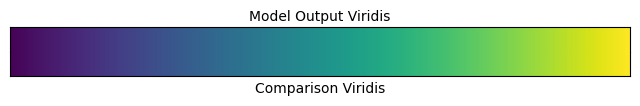

In [67]:
def plot_colorramps(colorramp: pd.DataFrame, comparison_ramp: pd.DataFrame=None) ->plt.figure:
    ramp_name = f"{colorramp.colormap_name.unique()[0].split('.')[-1]}"
    figsize = (8, 1)
    comparison_coloramp_ax = None
    if comparison_ramp is not None:
        fig, axes = plt.subplots(figsize=figsize, nrows=2)
        colorramp_ax, comparison_coloramp_ax = axes
    else:
        fig, colorramp_ax = plt.subplots(figsize=figsize)
    plt.subplots_adjust(hspace=0.0, top=.6)

    colorramp_ax.axis(xmin=0, xmax=len(colorramp))
    colorramp_ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    for index, color in enumerate(np.array(colorramp[['red', 'green', 'blue']])):
        colorramp_ax.axvspan(index, index + 1, color=color)
    
    colorramp_ax.set_xlabel(f"Model Output {ramp_name.title()}", labelpad=5)
    colorramp_ax.xaxis.set_label_position('top')
    colorramp_ax.spines['bottom'].set_visible(False)
    if not comparison_coloramp_ax:
        return fig

    comparison_coloramp_ax.axis(xmin=0, xmax=len(colorramp))
    comparison_coloramp_ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    comparison_coloramp_ax.set_xlabel(f"Comparison {ramp_name.title()}")
    comparison_coloramp_ax.spines['top'].set_visible(False)

    for index, color in enumerate(np.array(comparison_ramp[['red', 'green', 'blue']])):
        comparison_coloramp_ax.axvspan(index, index + 1, color=color)
    return fig


f = plot_colorramps(viridis, viridis)
# plt.tight_layout()
display("Ideal Output")

In [78]:


def generate_from_model(label, 
                        red, green, blue, 
                        previous_red, previous_green, previous_blue, 
                        start_red, start_green, start_blue, 
                        middle_red, middle_green, middle_blue,
                        end_red, end_green, end_blue,
                        cos_theta_start, cos_theta_previous, cos_theta_end, 
                        cos_theta_middle
    ):
    
    data = []
    for _ in range(256):
        data.append([
            red, green, blue, 
            previous_red, previous_green, previous_blue, 
            start_red, start_green, start_blue,
            middle_red, middle_green, middle_blue,
            end_red, end_green, end_blue,
            cos_theta_start, cos_theta_previous, cos_theta_end,  cos_theta_middle
            ])
        next_red, next_green, next_blue = xgb_reg.predict(np.array([data[-1]]))[0]

        previous_red = red
        previous_green = green
        previous_blue = blue

        red = next_red
        green = next_green
        blue = next_blue

        rgb_vector = np.array([red, green, blue])
        rgb_magnitude = np.linalg.norm(rgb_vector)

        start_rgb_vector = np.array([start_red, start_green, start_blue])
        start_rgb_magnitude = np.linalg.norm(start_rgb_vector)

        middle_rgb_vector = np.array([middle_red, middle_green, middle_blue])
        middle_rgb_magnitude = np.linalg.norm(middle_rgb_vector)
        
        previous_rgb_vector = np.array([previous_red, previous_green, previous_blue])
        previous_rgb_magnitude = np.linalg.norm(previous_rgb_vector)

        end_rgb_vector = np.array([end_red, end_green, end_blue])
        end_rgb_magnitude = np.linalg.norm(end_rgb_vector)

        cos_theta_start = np.dot(rgb_vector, start_rgb_vector) / (rgb_magnitude * start_rgb_magnitude)
        cos_theta_middle = np.dot(rgb_vector, middle_rgb_vector) / (rgb_magnitude * middle_rgb_magnitude)
        cos_theta_previous = np.dot(rgb_vector, previous_rgb_vector) / (rgb_magnitude * previous_rgb_magnitude)
        cos_theta_end = np.dot(rgb_vector, end_rgb_vector) / (rgb_magnitude * end_rgb_magnitude)
    df = pd.DataFrame(data, columns=dependent_variables)
    df['colormap_name'] = label
    return df


test_name = "perceptually_uniform_sequential.viridis"
# test_name = "scientific.Acton_256_r"
# test_name = "sequential.PuBuGn"
colorramp_df = dataset[dataset.colormap_name == test_name]
label = colorramp_df.colormap_name.unique()[0]
first_row = colorramp_df[dependent_variables].iloc[0].T
data = (generate_from_model(label, **{key: val for key, val in zip(first_row.index, first_row)}))

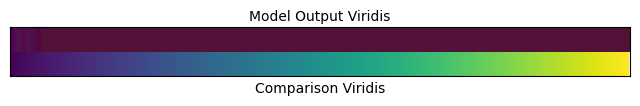

In [79]:
data[data[[c for c in data if c != 'colormap_name']] >= 1] = 1
data[data[[c for c in data if c != 'colormap_name']] < 0] = 0
f = plot_colorramps(data, colorramp_df)

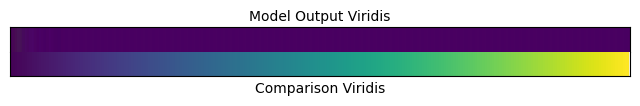

In [55]:
data[data[[c for c in data if c != 'colormap_name']] >= 1] = 1
data[data[[c for c in data if c != 'colormap_name']] < 0] = 0
f = plot_colorramps(data, colorramp_df)


In [42]:
data.describe()

,red,green,blue,previous_red,previous_green,previous_blue,start_red,start_green,start_blue,end_red,end_green,end_blue,middle_red,middle_green,middle_blue,cos_theta_start,cos_theta_middle,cos_theta_previous,cos_theta_end
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,2.560000e+02,2.560000e+02,2.560000e+02,256.000000,2.560000e+02,256.000000,2.560000e+02,2.560000e+02,2.560000e+02,256.000000,256.000000,256.000000,256.000000
mean,0.165000,0.086527,0.200147,0.164331,0.086190,0.199272,1.462000e-03,4.660000e-04,1.386600e-02,0.735683,2.159060e-01,0.330245,9.883620e-01,9.983640e-01,6.449240e-01,0.794243,0.985880,0.894528,0.901607
std,0.012626,0.006910,0.038450,0.016236,0.008756,0.040101,4.345304e-19,1.086326e-19,3.476243e-18,0.000000,2.780995e-17,0.000000,3.337193e-16,3.337193e-16,2.224796e-16,0.050444,0.017254,0.038879,0.036628
min,0.002267,0.001270,0.018570,0.001462,0.000466,0.013866,1.462000e-03,4.660000e-04,1.386600e-02,0.735683,2.159060e-01,0.330245,9.883620e-01,9.983640e-01,6.449240e-01,0.691887,0.714310,0.534229,0.515838
25%,0.160198,0.084704,0.163480,0.160198,0.084704,0.163480,1.462000e-03,4.660000e-04,1.386600e-02,0.735683,2.159060e-01,0.330245,9.883620e-01,9.983640e-01,6.449240e-01,0.752353,0.985170,0.862256,0.876583
50%,0.161276,0.085532,0.168876,0.161276,0.085532,0.166967,1.462000e-03,4.660000e-04,1.386600e-02,0.735683,2.159060e-01,0.330245,9.883620e-01,9.983640e-01,6.449240e-01,0.805017,0.988133,0.897997,0.894377
75%,0.172338,0.086744,0.237888,0.172338,0.086744,0.237888,1.462000e-03,4.660000e-04,1.386600e-02,0.735683,2.159060e-01,0.330245,9.883620e-01,9.983640e-01,6.449240e-01,0.841158,0.989351,0.921508,0.929692
max,0.173823,0.097631,0.239987,0.173823,0.097631,0.239987,1.462000e-03,4.660000e-04,1.386600e-02,0.735683,2.159060e-01,0.330245,9.883620e-01,9.983640e-01,6.449240e-01,0.999275,0.999275,0.948696,0.948715
